In [1]:
import pandas as pd

X_train = pd.read_csv(
    "../Processed/titanic/seed_42/X_train.csv"
)

X_test = pd.read_csv(
    "../Processed/titanic/seed_42/X_test.csv"
)

y_train = pd.read_csv(
    "../Processed/titanic/seed_42/y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    "../Processed/titanic/seed_42/y_test.csv"
).squeeze("columns")

In [2]:
print(X_train.shape, X_test.shape)
print(X_train.columns.equals(X_test.columns))
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

(1047, 10) (262, 10)
True
0
0


In [8]:
print(pycaret_model.steps)

[('placeholder', None), ('trained_model', LGBMClassifier(n_jobs=-1, random_state=42))]


In [9]:
lightgbm_model = pycaret_model.steps[-1][1]

print(type(lightgbm_model))
print(lightgbm_model)

<class 'lightgbm.sklearn.LGBMClassifier'>
LGBMClassifier(n_jobs=-1, random_state=42)


In [10]:
import shap
import matplotlib.pyplot as plt

explanation_data = X_test.sample(
    min(100, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(lightgbm_model)
shap_values = explainer(explanation_data)

print("SHAP shape:", shap_values.shape)

SHAP shape: (100, 10)


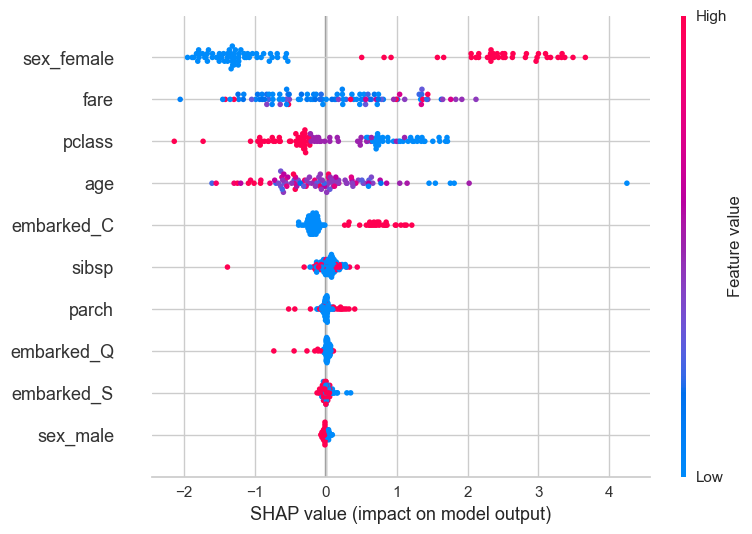

In [11]:
output_folder = (
    PROJECT_ROOT
    / "Results"
    / "explanations"
    / "pycaret"
)

output_folder.mkdir(parents=True, exist_ok=True)

shap.plots.beeswarm(
    shap_values,
    show=False,
    max_display=15
)

plt.tight_layout()
plt.savefig(
    output_folder / "titanic_seed_42_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [14]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
MODELS_ROOT = PROJECT_ROOT / "Models"

for file in MODELS_ROOT.rglob("*tpot*"):
    if file.is_file():
        print(file)

In [24]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
SEED_FOLDER = PROJECT_ROOT / "Processed" / "titanic" / "seed_42"

X_train = pd.read_csv(SEED_FOLDER / "X_train.csv")
X_test = pd.read_csv(SEED_FOLDER / "X_test.csv")
y_train = pd.read_csv(SEED_FOLDER / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(SEED_FOLDER / "y_test.csv").squeeze("columns")

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Features:", X_train.columns.tolist())

Train: (1047, 10)
Test: (262, 10)
Features: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


In [25]:
from copy import copy

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline, make_union
from sklearn.preprocessing import FunctionTransformer

tpot_pipeline = make_pipeline(
    make_union(
        FunctionTransformer(copy),
        FunctionTransformer(copy)
    ),
    RandomForestClassifier(
        bootstrap=False,
        criterion="gini",
        max_features=0.2,
        min_samples_leaf=1,
        min_samples_split=18,
        n_estimators=100,
        random_state=42
    )
)

print(tpot_pipeline)

Pipeline(steps=[('featureunion',
                 FeatureUnion(transformer_list=[('functiontransformer-1',
                                                 FunctionTransformer(func=<function copy at 0x000001D2ABB05260>)),
                                                ('functiontransformer-2',
                                                 FunctionTransformer(func=<function copy at 0x000001D2ABB05260>))])),
                ('randomforestclassifier',
                 RandomForestClassifier(bootstrap=False, max_features=0.2,
                                        min_samples_split=18,
                                        random_state=42))])


In [26]:
tpot_pipeline.fit(X_train, y_train)

print("Pipeline fitted successfully.")

Pipeline fitted successfully.


In [27]:
from sklearn.metrics import accuracy_score, f1_score

tpot_predictions = tpot_pipeline.predict(X_test)

tpot_accuracy = accuracy_score(y_test, tpot_predictions)
tpot_macro_f1 = f1_score(y_test, tpot_predictions, average="macro")

print("Test accuracy:", round(tpot_accuracy, 6))
print("Test macro F1:", round(tpot_macro_f1, 6))

Test accuracy: 0.812977
Test macro F1: 0.799891


In [28]:
import joblib

TPOT_MODEL_FOLDER = PROJECT_ROOT / "Models" / "tpot"
TPOT_MODEL_FOLDER.mkdir(parents=True, exist_ok=True)

TPOT_MODEL_PATH = (
    TPOT_MODEL_FOLDER
    / "titanic_seed_42_pipeline.joblib"
)

joblib.dump(tpot_pipeline, TPOT_MODEL_PATH)

print("Saved:", TPOT_MODEL_PATH.exists())
print("Path:", TPOT_MODEL_PATH)

Saved: True
Path: c:\Users\souha\Downloads\Human Centered AutoML Thesis\Models\tpot\titanic_seed_42_pipeline.joblib


In [29]:
import shap
import numpy as np
import matplotlib.pyplot as plt

background = X_train.sample(
    n=min(30, len(X_train)),
    random_state=42
)

explanation_data = X_test.sample(
    n=min(50, len(X_test)),
    random_state=42
)

print("Background:", background.shape)
print("Explanation data:", explanation_data.shape)

Background: (30, 10)
Explanation data: (50, 10)


In [30]:
def tpot_predict_survival(data):
    data = pd.DataFrame(
        data,
        columns=X_train.columns
    )

    return tpot_pipeline.predict_proba(data)[:, 1]

In [31]:
test_probabilities = tpot_predict_survival(
    explanation_data.iloc[:3]
)

print(test_probabilities)

[0.94589777 0.90208915 0.18892178]


In [32]:
tpot_explainer = shap.Explainer(
    tpot_predict_survival,
    background,
    algorithm="permutation",
    feature_names=X_train.columns.tolist()
)

tpot_shap_values = tpot_explainer(
    explanation_data,
    max_evals=2 * X_train.shape[1] + 1
)

print("SHAP shape:", tpot_shap_values.values.shape)

PermutationExplainer explainer: 51it [00:11,  4.28it/s]                        

SHAP shape: (50, 10)


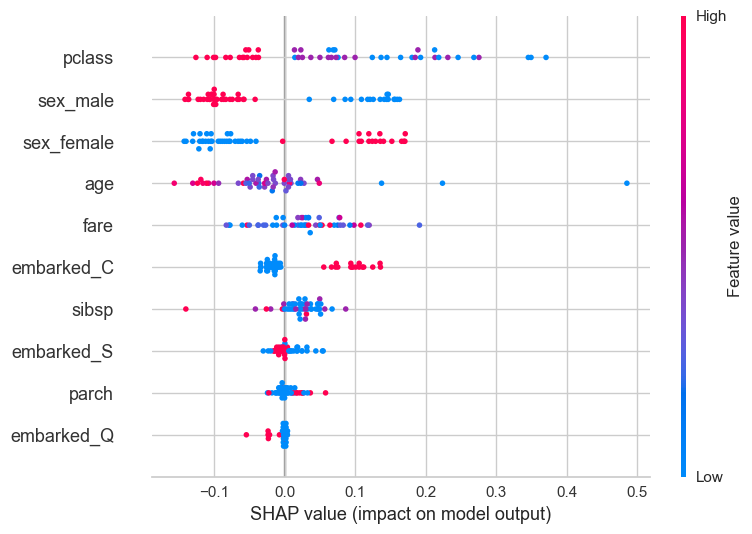

In [33]:
TPOT_EXPLANATION_FOLDER = (
    PROJECT_ROOT
    / "Results"
    / "explanations"
    / "tpot"
)

TPOT_EXPLANATION_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

shap.plots.beeswarm(
    tpot_shap_values,
    max_display=10,
    show=False
)

plt.tight_layout()

plt.savefig(
    TPOT_EXPLANATION_FOLDER
    / "titanic_seed_42_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

matches = list(PROJECT_ROOT.rglob("*titanic*42*"))

for file in matches:
    if file.is_file() or file.is_dir():
        print(file)

c:\Users\souha\Downloads\Human Centered AutoML Thesis\Models\pycaret\titanic_seed_42.pkl
c:\Users\souha\Downloads\Human Centered AutoML Thesis\Models\tpot\titanic_seed_42_pipeline.joblib
c:\Users\souha\Downloads\Human Centered AutoML Thesis\Results\pycaret_leaderboard_titanic_seed_42.csv
c:\Users\souha\Downloads\Human Centered AutoML Thesis\Results\tpot_pipeline_titanic_seed_42.py
c:\Users\souha\Downloads\Human Centered AutoML Thesis\Results\tpot_result_titanic_seed_42.csv
c:\Users\souha\Downloads\Human Centered AutoML Thesis\Results\explanations\pycaret\titanic_seed_42_shap_summary.png
c:\Users\souha\Downloads\Human Centered AutoML Thesis\Results\explanations\tpot\titanic_seed_42_shap_summary.png


In [35]:
import pandas as pd

SEED_FOLDER = PROJECT_ROOT / "Processed" / "titanic" / "seed_42"

X_train = pd.read_csv(SEED_FOLDER / "X_train.csv")
X_test = pd.read_csv(SEED_FOLDER / "X_test.csv")
y_train = pd.read_csv(SEED_FOLDER / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(SEED_FOLDER / "y_test.csv").squeeze("columns")

print(X_train.shape, X_test.shape)

(1047, 10) (262, 10)


In [36]:
import h2o

h2o.init(
    nthreads=2,
    max_mem_size="4G"
)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 21.0.9+7-LTS-338, mixed mode, sharing)
  Starting server from C:\Users\souha\anaconda3\envs\geoenv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\souha\AppData\Local\Temp\tmps30q5jid
  JVM stdout: C:\Users\souha\AppData\Local\Temp\tmps30q5jid\h2o_souha_started_from_python.out
  JVM stderr: C:\Users\souha\AppData\Local\Temp\tmps30q5jid\h2o_souha_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,04 secs
H2O_cluster_timezone:,Europe/Brussels
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,2 months and 10 days
H2O_cluster_name:,H2O_from_python_souha_mc1892
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.984 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [38]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

for path in PROJECT_ROOT.rglob("*"):
    if path.is_file() and (
        "h2o" in path.name.lower()
        or "titanic" in path.name.lower()
        or "stackedensemble" in path.name.lower()
        or "gbm" in path.name.lower()
        or "drf" in path.name.lower()
    ):
        print(path)

c:\Users\souha\Downloads\Human Centered AutoML Thesis\Datasets\titanic.csv
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\h2o.py
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\automl\autoh2o.py
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\automl\__pycache__\autoh2o.cpython-311.pyc
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\backend\bin\h2o.jar
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\estimators\gbm.py
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\estimators\stackedensemble.py
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\estimators\__pycache__\gbm.cpython-311.pyc
c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\estimators\__pycache__\stackedensemble.cpython-311.pyc
c:\Users\souha\Down

In [3]:
import h2o

print(h2o.__version__)

h2o.init(
    nthreads=2,
    max_mem_size="4G"
)

3.46.0.10
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 21.0.9+7-LTS-338, mixed mode, sharing)
  Starting server from C:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\souha\AppData\Local\Temp\tmpld8x2in6
  JVM stdout: C:\Users\souha\AppData\Local\Temp\tmpld8x2in6\h2o_souha_started_from_python.out
  JVM stderr: C:\Users\souha\AppData\Local\Temp\tmpld8x2in6\h2o_souha_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Europe/Brussels
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 20 days
H2O_cluster_name:,H2O_from_python_souha_kiy2uo
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.984 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [4]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

H2O_MODEL_PATH = (
    PROJECT_ROOT
    / "Results"
    / "h2o"
    / "titanic"
    / "seed_42"
    / "StackedEnsemble_BestOfFamily_6_AutoML_7_20260726_215010"
)

h2o_model = h2o.load_model(str(H2O_MODEL_PATH))

print("Model ID:", h2o_model.model_id)
print("Algorithm:", h2o_model.algo)

Model ID: StackedEnsemble_BestOfFamily_6_AutoML_7_20260726_215010
Algorithm: stackedensemble


In [6]:
base_model_info = h2o_model.params["base_models"]["actual"]

print(base_model_info)

[{'__meta': {'schema_version': 3, 'schema_name': 'KeyV3', 'schema_type': 'Key<Keyed>'}, 'name': 'GBM_lr_annealing_selection_AutoML_7_20260726_215010_select_model', 'type': 'Key<Keyed>', 'URL': None}, {'__meta': {'schema_version': 3, 'schema_name': 'KeyV3', 'schema_type': 'Key<Keyed>'}, 'name': 'DeepLearning_grid_1_AutoML_7_20260726_215010_model_2', 'type': 'Key<Keyed>', 'URL': None}, {'__meta': {'schema_version': 3, 'schema_name': 'KeyV3', 'schema_type': 'Key<Keyed>'}, 'name': 'DRF_1_AutoML_7_20260726_215010', 'type': 'Key<Keyed>', 'URL': None}, {'__meta': {'schema_version': 3, 'schema_name': 'KeyV3', 'schema_type': 'Key<Keyed>'}, 'name': 'GLM_1_AutoML_7_20260726_215010', 'type': 'Key<Keyed>', 'URL': None}, {'__meta': {'schema_version': 3, 'schema_name': 'KeyV3', 'schema_type': 'Key<Keyed>'}, 'name': 'XRT_1_AutoML_7_20260726_215010', 'type': 'Key<Keyed>', 'URL': None}]


In [7]:
base_model_ids = [
    item["name"] if isinstance(item, dict) else item
    for item in base_model_info
]

for model_id in base_model_ids:
    print(model_id)

GBM_lr_annealing_selection_AutoML_7_20260726_215010_select_model
DeepLearning_grid_1_AutoML_7_20260726_215010_model_2
DRF_1_AutoML_7_20260726_215010
GLM_1_AutoML_7_20260726_215010
XRT_1_AutoML_7_20260726_215010


In [8]:
available_base_models = []

for model_id in base_model_ids:
    model = h2o.get_model(model_id)

    if model is not None:
        available_base_models.append(model)
        print("Available:", model.model_id, "|", model.algo)
    else:
        print("Not loaded:", model_id)

Available: GBM_lr_annealing_selection_AutoML_7_20260726_215010_select_model | gbm
Available: DeepLearning_grid_1_AutoML_7_20260726_215010_model_2 | deeplearning
Available: DRF_1_AutoML_7_20260726_215010 | drf
Available: GLM_1_AutoML_7_20260726_215010 | glm
Available: XRT_1_AutoML_7_20260726_215010 | drf


In [9]:
gbm_model = h2o.get_model(
    "GBM_lr_annealing_selection_AutoML_7_20260726_215010_select_model"
)

print("Explained model:", gbm_model.model_id)
print("Algorithm:", gbm_model.algo)

Explained model: GBM_lr_annealing_selection_AutoML_7_20260726_215010_select_model
Algorithm: gbm


In [10]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
SEED_FOLDER = PROJECT_ROOT / "Processed" / "titanic" / "seed_42"

X_test = pd.read_csv(SEED_FOLDER / "X_test.csv")
y_test = pd.read_csv(SEED_FOLDER / "y_test.csv").squeeze("columns")

h2o_test_pd = X_test.copy()
h2o_test_pd["target"] = y_test.to_numpy()

h2o_test = h2o.H2OFrame(h2o_test_pd)
h2o_test["target"] = h2o_test["target"].asfactor()

print(h2o_test.shape)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
(262, 11)


# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

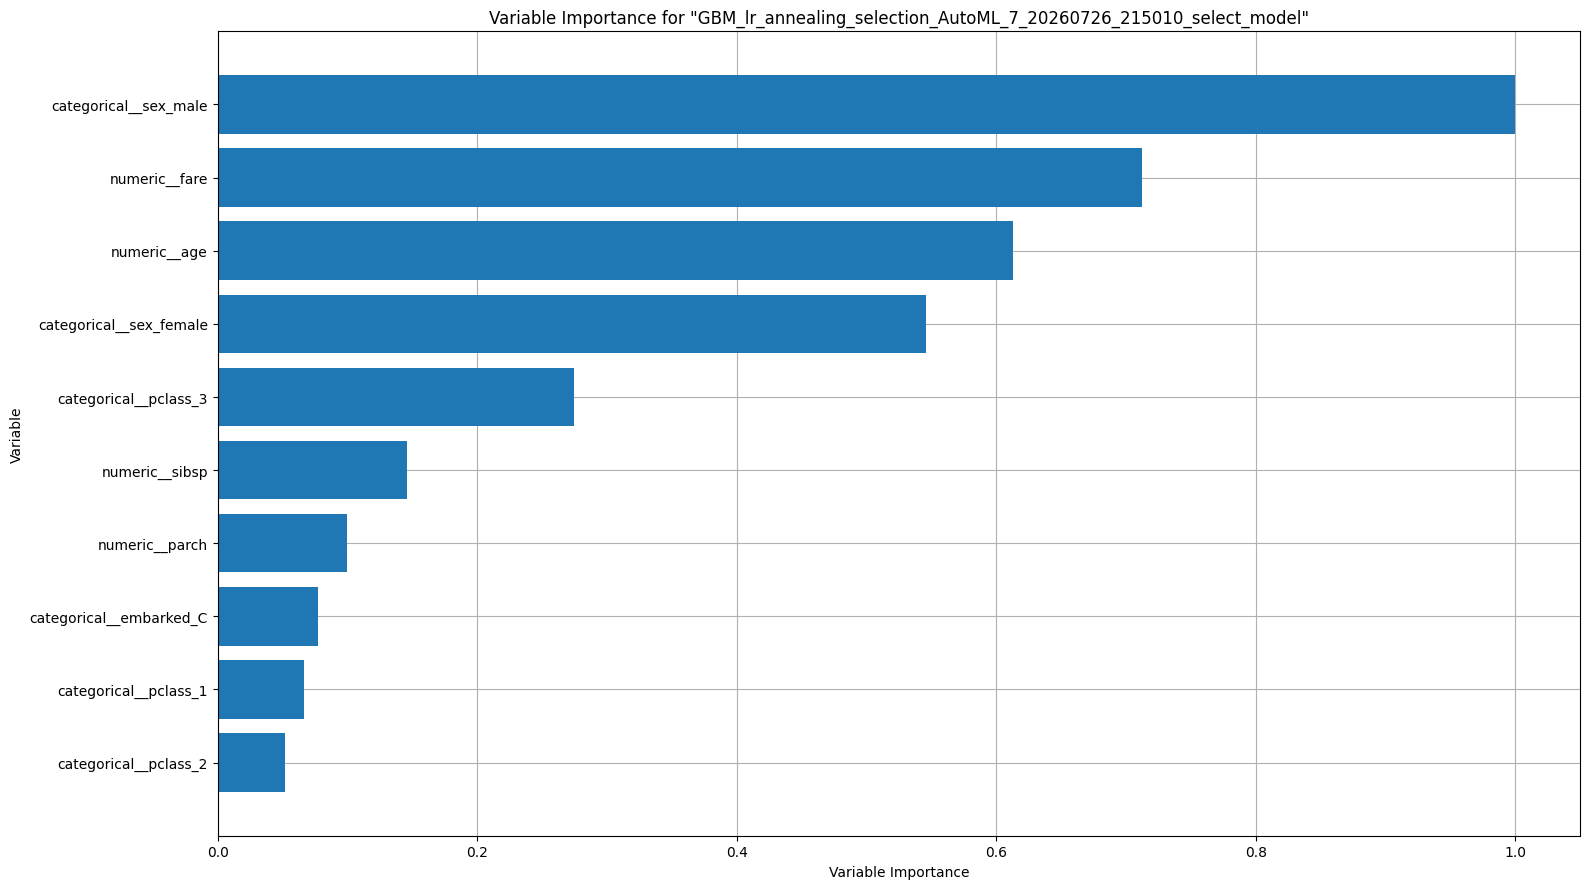

H2OValueError: Column ''categorical__sex_male'' does not exist in the frame

In [11]:
h2o_explanation = h2o.explain(
    gbm_model,
    h2o_test,
    include_explanations=[
        "varimp",
        "shap_summary"
    ]
)

In [12]:
H2O_OUTPUT_FOLDER = (
    PROJECT_ROOT
    / "Results"
    / "explanations"
    / "h2o"
)

H2O_OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

h2o_varimp = gbm_model.varimp(use_pandas=True)

h2o_varimp.to_csv(
    H2O_OUTPUT_FOLDER
    / "titanic_seed_42_gbm_variable_importance.csv",
    index=False
)

h2o_varimp.head(10)

,variable,relative_importance,scaled_importance,percentage
0,categorical__sex_male,224.179306,1.000000,0.273661
1,numeric__fare,159.656647,0.712183,0.194896
2,numeric__age,137.490219,0.613305,0.167837
3,categorical__sex_female,122.322594,0.545646,0.149322
4,categorical__pclass_3,61.624477,0.274889,0.075226
5,numeric__sibsp,32.733471,0.146015,0.039958
6,numeric__parch,22.381241,0.099836,0.027321
7,categorical__embarked_C,17.283646,0.077097,0.021099
8,categorical__pclass_1,14.947991,0.066679,0.018247
9,categorical__pclass_2,11.639917,0.051922,0.014209


In [13]:
h2o_contributions = gbm_model.predict_contributions(h2o_test)

h2o_contributions_df = h2o_contributions.as_data_frame()

h2o_contributions_df.to_csv(
    H2O_OUTPUT_FOLDER
    / "titanic_seed_42_gbm_shap_contributions.csv",
    index=False
)

h2o_contributions_df.head()

contributions progress: |████████████████████████████████████████████████████████| (done) 100%


c:\Users\souha\Downloads\Human Centered AutoML Thesis\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,numeric__age,numeric__sibsp,numeric__parch,numeric__fare,categorical__pclass_1,categorical__pclass_2,categorical__pclass_3,categorical__sex_female,categorical__sex_male,categorical__embarked_C,categorical__embarked_Q,categorical__embarked_S,BiasTerm
0,-0.322721,0.032783,-0.027887,-0.05818,-0.112911,-0.007575,0.108588,-0.315201,-0.61961,-0.097404,-0.015909,-0.036928,-0.547149
1,-0.322721,0.032783,-0.027887,-0.05818,-0.112911,-0.007575,0.108588,-0.315201,-0.61961,-0.097404,-0.015909,-0.036928,-0.547149
2,-0.322721,0.032783,-0.027887,-0.05818,-0.112911,-0.007575,0.108588,-0.315201,-0.61961,-0.097404,-0.015909,-0.036928,-0.547149
3,-0.322721,0.032783,-0.027887,-0.05818,-0.112911,-0.007575,0.108588,-0.315201,-0.61961,-0.097404,-0.015909,-0.036928,-0.547149
4,-0.322721,0.032783,-0.027887,-0.05818,-0.112911,-0.007575,0.108588,-0.315201,-0.61961,-0.097404,-0.015909,-0.036928,-0.547149
